In [155]:
import numpy as np
import os

from maui_analysis.process_behavior import pull_fictrac_speed, pull_fictrac_timestamps, save_speed_data
from maui_analysis.data_alignment import *
from maui_codebook.visualizations import *
import xarray as xr
import glob

In [165]:
fly = '09'
win = '1'

In [166]:
path_to_voltage_csv = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/')[0]
voltage_csv = glob.glob(path_to_voltage_csv + '*VoltageRecording_001.csv')[0]
dat_file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10_GC8m_fly{fly}_win0{win}_trial01/*.dat')[0]
print(voltage_csv)
processed_path = '/Volumes/AhmedLab/princess/data/pIP10/processed'
experiment_path = glob.glob(processed_path + f'/pIP10_TSeries_*fly{fly}_win0{win}*')[0]

SLICES = 11
DIMENSIONS = [512,512,11]

/Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001_Cycle00001_VoltageRecording_001.csv


Fly02Win01
- rois = [ [6,8], [6,14], [6,11], [6,19], [7,2], [7,10], [8,9],  [8,14], [9,6]]
Fly03Win01
- rois = [ [4,4], [4,16], [5,18], [6,1],  [7,4]]
Fly03Win02
- rois =
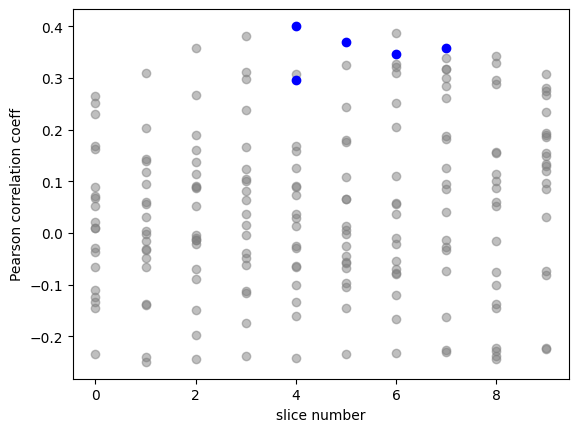

In [167]:

hf_path = f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/synced_data.h5'
if not glob.glob(hf_path):
    save_path = glob.glob(os.path.dirname(hf_path))[0]
    save_speed_data(dat_file, voltage_csv, save_path=save_path)
    # # takes ~2-3 minutes
synced_data_hf = glob.glob(hf_path)[0]


In [168]:
# process fictrac data
beh_speed = pull_fictrac_speed(dat_file)
beh_timestamps = pull_fictrac_timestamps(voltage_csv, beh_speed)

# align to scope data
maui_vol_timestamps = align_scopetimes_to_behaviortimes(path_to_voltage_csv, synced_data_hf, SLICES)
walk_times, walk_speeds = open_processed_behavior_data(synced_data_hf)
# takes Xx minutes

<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>


In [169]:
from scipy.interpolate import interp1d
def interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps):
    f = interp1d(walk_times, walk_speeds)
    speed_new = f(maui_vol_timestamps)
    return speed_new

In [170]:
synced_walk_speeds = interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps)

In [171]:
file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/20_supervoxels.h5')[0]
with h5py.File(file, "r") as f:
    print(f.keys())
    cluster_labels = f["labels"][...]
    signal = f["signal"][...]

signal = signal[...,:len(maui_vol_timestamps)]


signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': maui_vol_timestamps/1000}
)

behav_xr = xr.DataArray(
    data = synced_walk_speeds,
    dims = ['time'],
    coords = {'time': maui_vol_timestamps/1000}
)

<KeysViewHDF5 ['labels']>


KeyError: "Unable to synchronously open object (object 'signal' doesn't exist)"

In [124]:
def plot_zscored_activity(clusters_toplot, signal_xarray):
    fig, ax = plt.subplots(figsize=(20, len(clusters_toplot)))
    yshift = 1
    # n_lines = len(clusters_toplot)
    palette_colors = sns.color_palette("Blues", len(clusters_toplot))

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")

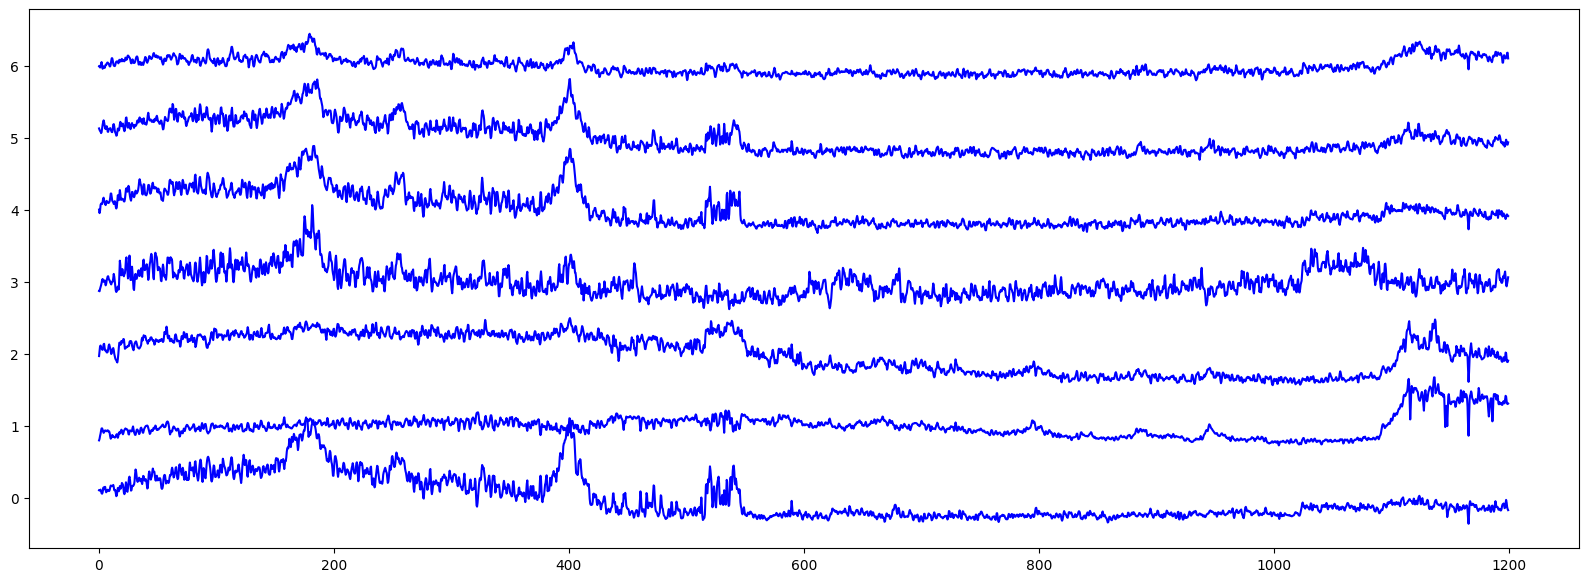

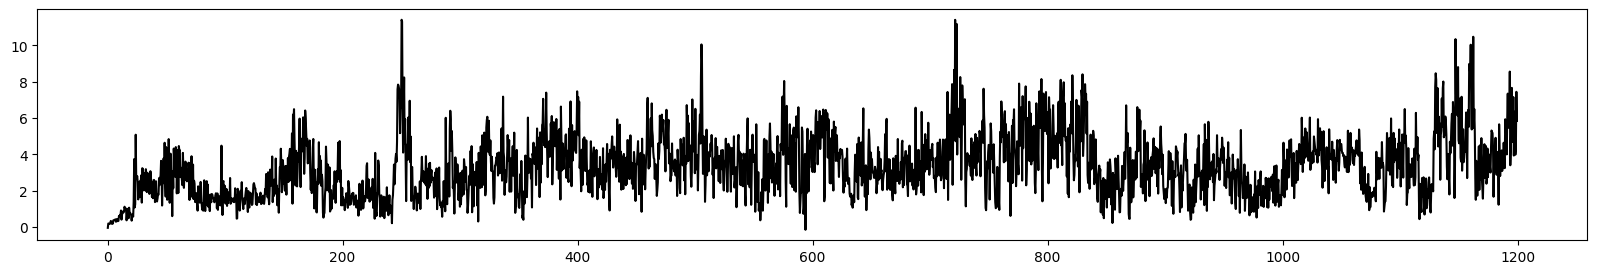

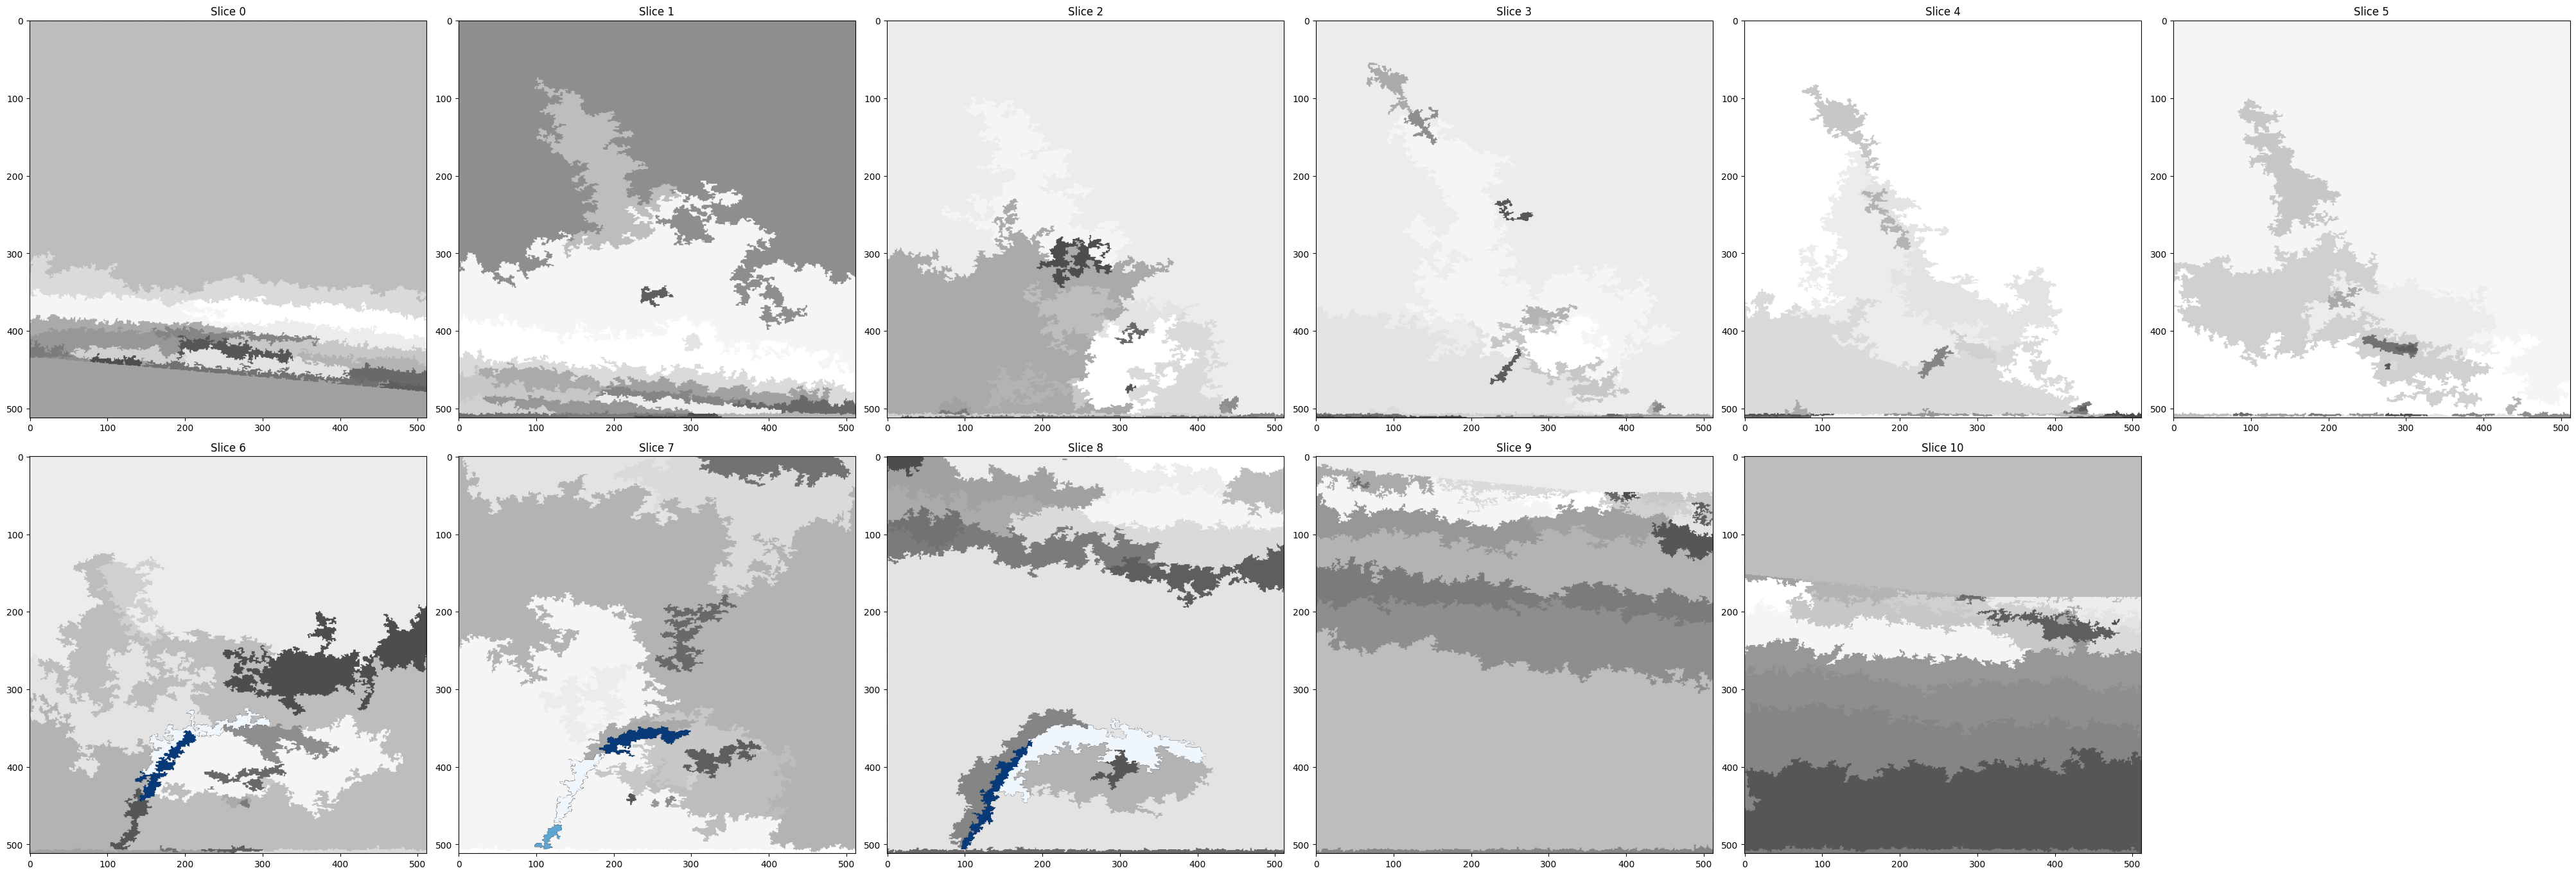

In [154]:
rois = [ [8,5], [8,6], [7,10], [7,14], [7,19], [6,0], [6,11]]
# rois = [4,4], [4,16], [5,18]
fig = plot_zscored_activity(rois, signal_xr)
plt.figure(figsize=(20, 3))
plt.plot(maui_vol_timestamps/1000,synced_walk_speeds, color = 'k')
fig2 = plot_spatial_location(rois, cluster_labels, DIMENSIONS)

In [152]:
from scipy.stats import pearsonr

# correlation = pearsonr(roi_arr, synced_walk_speeds).statistic()
# print(len(synced_walk_speeds), len(roi_data))
correlation = xr.corr(signal_xr, behav_xr, dim='time')


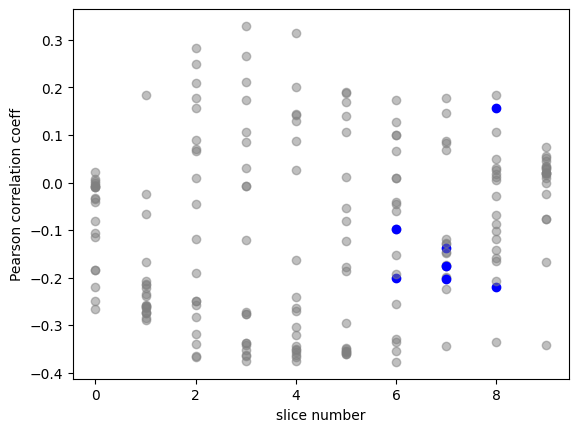

In [153]:
# plot where x is z-poss, y is correlation

for iSlice in range(signal_xr['zposs'].max().values):
    # print(iSlice)
    to_plot = correlation.isel(zposs=iSlice)
    for i, corrs in enumerate(to_plot):

        if [iSlice, i] in rois:
            # plot pIP10 supervoxels in blue
            iCorr = correlation.isel(zposs=iSlice, roi=i)
            plt.scatter(iSlice, iCorr, color='b')
        else:
            # plot non-pIP10 supervoxels in gray
            plt.scatter(iSlice, corrs, color='gray', alpha=0.5)
        plt.xlabel('slice number')
        plt.ylabel('Pearson correlation coeff')
        # to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])

In [ ]:
# making control rois
